In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_curve,
    auc
)    

In [4]:
# -------------------------
# LOAD DATA
# -------------------------
df = pd.read_csv("student_data_expanded_5000.csv", sep=",")
df = df.drop_duplicates()

# -------------------------
# FEATURE ENGINEERING
# -------------------------
df["G3_class"] = (df["G3"] >= 10).astype(int)
df["avg_grade"] = (df["G1"] + df["G2"]) / 2
df["study_effort"] = df["studytime"] * df["absences"]
df["alcohol_index"] = df["Dalc"] + df["Walc"]


In [5]:
# -------------------------
# SPLIT
# -------------------------
X = df.drop(["G3", "G3_class"], axis=1)
y = df["G3_class"]

# -------------------------
# COLUMNS
# -------------------------
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# -------------------------
# PREPROCESSOR
# -------------------------
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [6]:
# -------------------------
# MODELS
# -------------------------
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier()
}

# -------------------------
# STORAGE
# -------------------------
results = {}
cv_results = {}


LogisticRegression
Accuracy: 0.860982391102873
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       313
           1       0.89      0.91      0.90       766

    accuracy                           0.86      1079
   macro avg       0.83      0.82      0.83      1079
weighted avg       0.86      0.86      0.86      1079



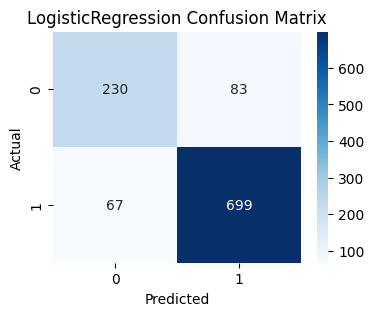

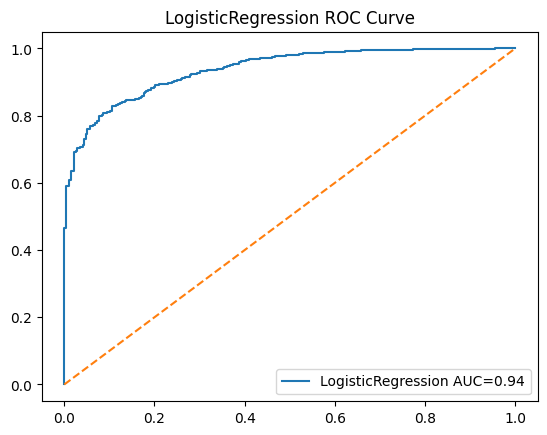


SVM
Accuracy: 0.8507877664504171
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       313
           1       0.88      0.91      0.90       766

    accuracy                           0.85      1079
   macro avg       0.82      0.81      0.82      1079
weighted avg       0.85      0.85      0.85      1079



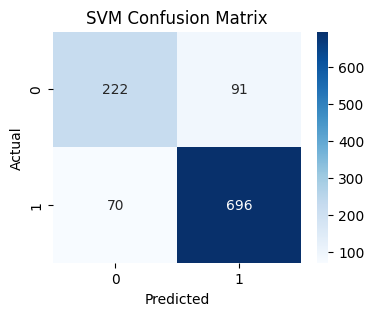

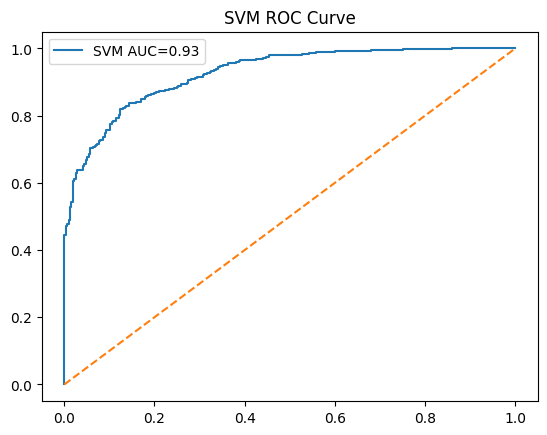


RandomForest
Accuracy: 0.8628359592215014
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       313
           1       0.90      0.91      0.90       766

    accuracy                           0.86      1079
   macro avg       0.84      0.83      0.83      1079
weighted avg       0.86      0.86      0.86      1079



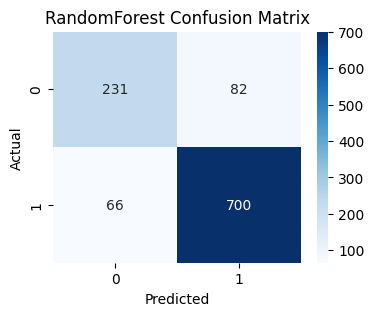

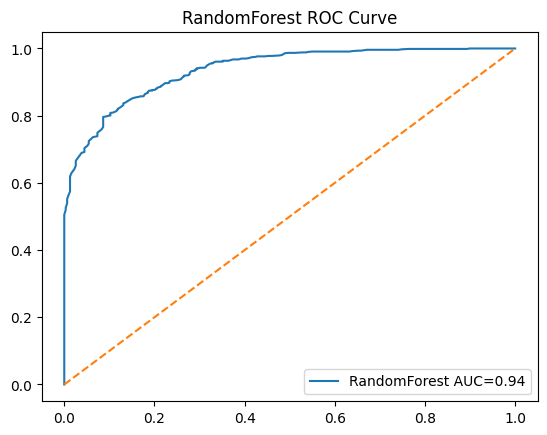


GradientBoosting
Accuracy: 0.8554216867469879
              precision    recall  f1-score   support

           0       0.75      0.74      0.75       313
           1       0.90      0.90      0.90       766

    accuracy                           0.86      1079
   macro avg       0.83      0.82      0.82      1079
weighted avg       0.85      0.86      0.86      1079



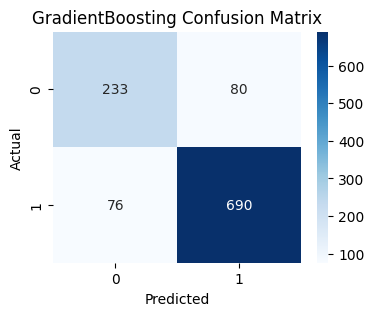

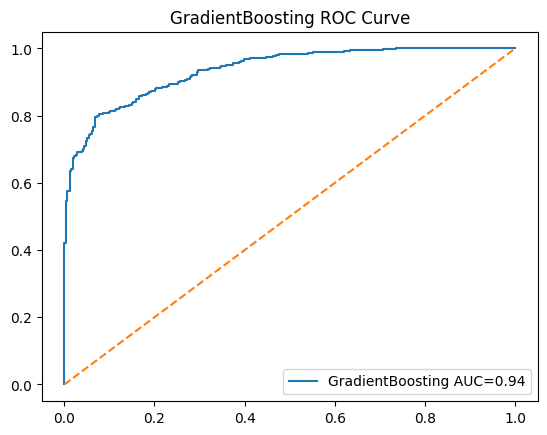

In [7]:
# -------------------------
# TRAIN LOOP
# -------------------------
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    # -------------------------
    # BASIC METRICS
    # -------------------------
    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print("\n====================")
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))

    # -------------------------
    # CONFUSION MATRIX
    # -------------------------
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # -------------------------
    # CROSS VALIDATION
    # -------------------------
    scores = cross_val_score(pipeline, X, y, cv=5)
    cv_results[name] = scores

    # -------------------------
    # ROC CURVE
    # -------------------------
    if hasattr(model, "predict_proba"):
        probs = pipeline.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")
        plt.plot([0,1],[0,1],"--")
        plt.title(f"{name} ROC Curve")
        plt.legend()
        plt.show()

  

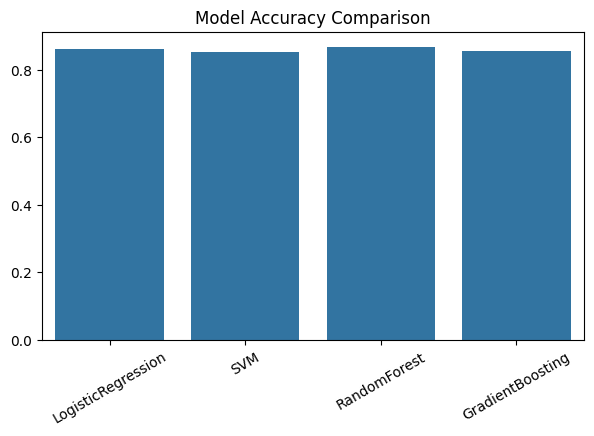

In [24]:
# -------------------------
# MODEL COMPARISON
# -------------------------
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

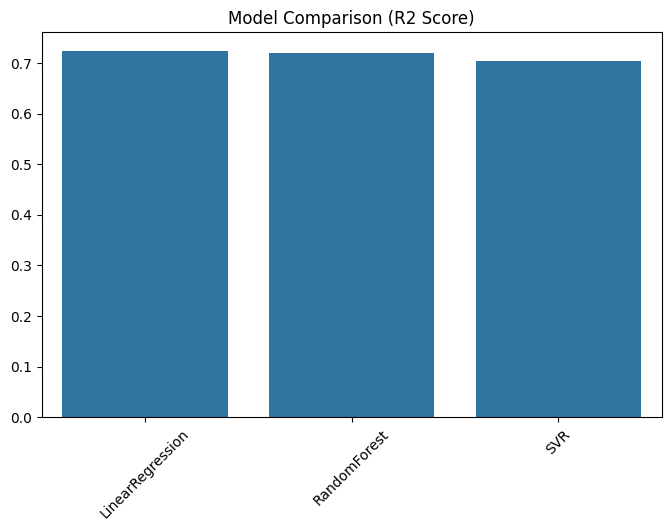

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=45)
plt.show()

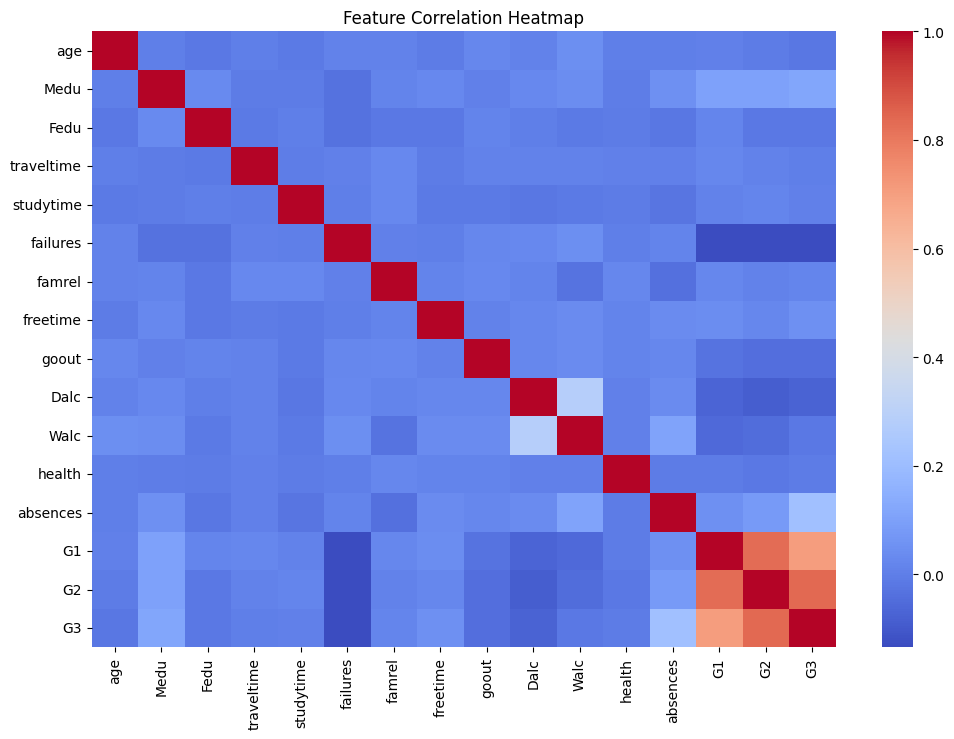

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

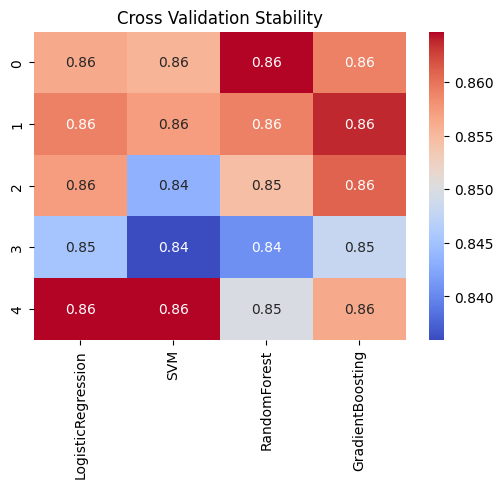

In [25]:
# CV STABILITY HEATMAP
# -------------------------
plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(cv_results), annot=True, cmap="coolwarm")
plt.title("Cross Validation Stability")
plt.show()

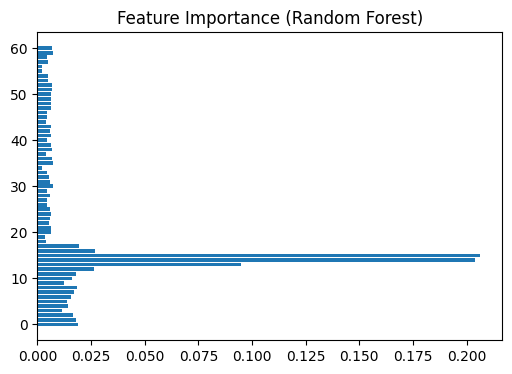

In [26]:
# -------------------------
# FEATURE IMPORTANCE (TREE MODELS ONLY)
# -------------------------
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200))
])

rf_model.fit(X_train, y_train)
importances = rf_model.named_steps["model"].feature_importances_

plt.figure(figsize=(6,4))
plt.barh(range(len(importances)), importances)
plt.title("Feature Importance (Random Forest)")
plt.show()